# 2d. WTI Crude Oil Meta-Model
### WTI Crude Oil Futures (cl1s)

In this notebook we develop the meta-model for WTI crude oil (cl1s). Meta-labelling uses a secondary model to decide whether to act on a primary model's signal. The primary signal says which way to trade, and the meta-model gives each of those signals a probability of being a genuine opportunity rather than noise.

We start from the assembled feature matrix built in notebook 1, which gives every instrument a common set of base features. On top of that we add a few WTI crude oil specific features, the latent regime features, and the primary-signal features, then reduce everything with PCA, label the trades with the triple-barrier method, and compare a range of models. Every feature is strictly backward looking, so nothing here uses information from the future.

## 1. Imports

We load the standard scientific Python stack together with scikit-learn, XGBoost and Keras. These cover the data handling, the classical models, and the neural networks used later on.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

np.random.seed(42)

## 2. Load the Feature Matrix

We load the assembled feature matrix and, for WTI crude oil, add the more specific data on top before running the triple-barrier method and the HMM for the regime state. The base features were built in the feature engineering notebook, and the idea is to keep a common set of base features that we can then enrich, so the meta-model has both general and WTI crude oil specific information to work with.

In [57]:
features = pd.read_parquet('../data/processed/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../data/processed/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (5024, 64)
Date range: 2020-01-03 → 2022-06-30
Instruments: ['cl1s', 'gc1s', 'hg1s', 'ho1s', 'ng1s', 'pl1s', 'rb1s', 'si1s']
Feature columns: 61


In [58]:
# Quick look at what we have, grouped by course bucket
feat_dict.groupby('course_bucket').size().sort_values(ascending=False)

course_bucket
base                      19
domain (metals)           11
TA                         8
domain (energy)            8
seasonality                6
Lecture 1                  5
meta-labeling              5
Lecture 2 (GMM)            4
Lecture 3 (HMM)            4
Lecture 2 (K-means)        2
Lecture 3 (basket HMM)     2
dtype: int64

## 3. Tier 1: Base Features

We keep the WTI crude oil rows (cl1s), sort them by date, and recap the Tier 1 base features. These are the general price and volatility features that apply to any instrument, such as returns, momentum, rolling volatility, and the trend-scanning t-statistics. They describe what prices have actually done and form the backbone that the later tiers build on.

In [59]:
wti = features[features['instrument'] == 'cl1s'].set_index('date').sort_index().copy()
print(wti.shape)
wti.head()

(628, 63)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,hmm_basket_turbulent_metals,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,cl1s,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,cl1s,0.0,0.030566,0.030108,0.021968,0.035516,0.077598,0.178520,0.009621,0.015894,...,0.007837,0.015823,54.0,0.998434,0.001323,2.0,0.75,NaN,NaN,0.0
2020-01-07,cl1s,-1.0,0.003489,0.003483,0.024803,0.033591,0.081081,0.182764,0.009578,0.015887,...,0.002866,0.011006,55.0,0.999299,0.001208,2.0,0.50,0.0,NaN,1.0
2020-01-08,cl1s,0.0,-0.009009,-0.009050,0.016402,0.036710,0.058939,0.155624,0.009757,0.015837,...,0.002576,0.010724,56.0,0.999323,0.002304,2.0,0.75,0.0,NaN,0.0
2020-01-09,cl1s,0.0,-0.049282,-0.050538,-0.024034,-0.015151,0.011446,0.083838,0.015425,0.017068,...,0.056907,0.063378,57.0,0.985763,0.001970,2.0,1.00,-1.0,NaN,1.0


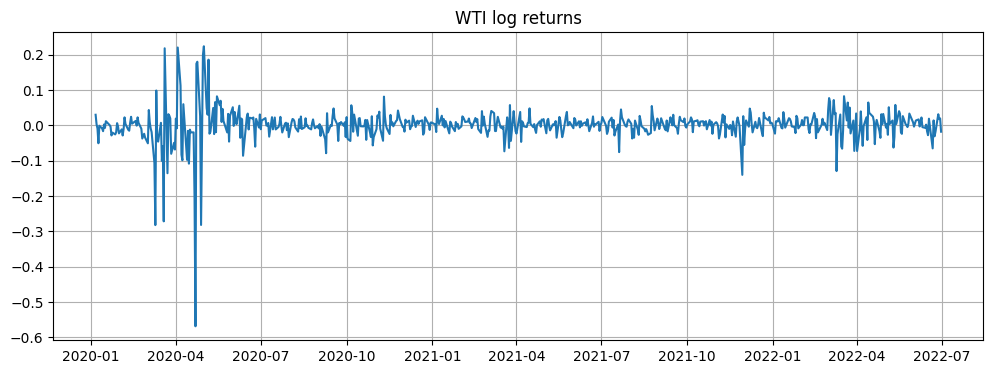

In [60]:
plt.figure(figsize=(12, 4))
plt.plot(wti.index, wti['logret_1d'])
plt.title('WTI crude oil (cl1s) log returns')
plt.grid(True)
plt.show()

In [61]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
wti[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,-0.018246,-0.081200,-0.135233,-0.028698,0.032111,0.022317,0.029915,0.027577,0.029909,0.005700,...,1.668874,16.657123,-0.126487,0.160438,10.0,-8.866872,-0.990656,11.771158,11.771158,60.0
2022-06-27,0.031623,-0.068497,-0.098684,-0.002163,0.080100,0.023483,0.030097,0.028119,0.030228,0.005444,...,1.664778,17.061100,-0.098423,0.197721,11.0,-6.877725,-2.156899,11.497975,11.497975,60.0
2022-06-28,0.017957,0.014525,-0.073790,-0.017718,0.064290,0.022550,0.029876,0.028263,0.030553,0.005139,...,1.660974,16.780195,-0.082087,0.219423,12.0,-4.056940,-2.833680,11.904422,11.904422,60.0
2022-06-29,0.019790,0.020247,-0.056152,-0.006481,0.156577,0.022935,0.028362,0.028291,0.030544,0.004800,...,1.604082,15.995568,-0.063740,0.243796,13.0,-1.885477,-3.159060,11.692984,11.692984,60.0
2022-06-30,-0.017875,0.033248,-0.057351,-0.020874,0.148824,0.023263,0.028438,0.028096,0.030183,0.004407,...,1.602051,14.973078,-0.080328,0.221760,14.0,-0.903275,-3.886410,11.174834,11.174834,60.0


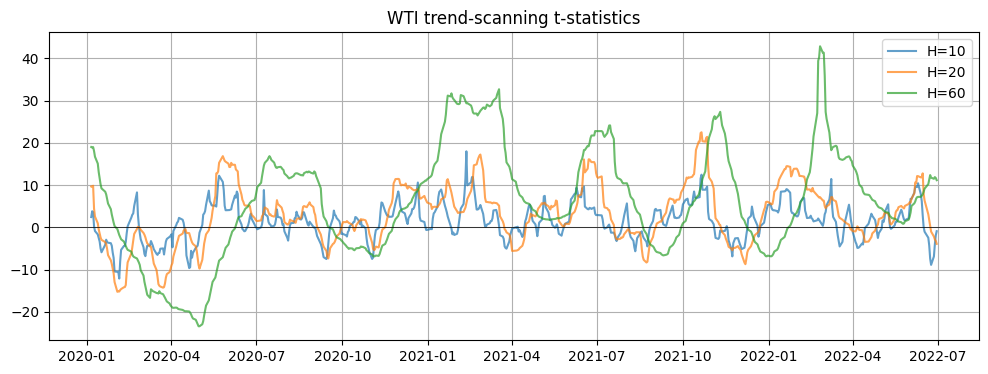

In [62]:
# Trend-scanning t-stats, Lecture 1, max |t| over several horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(wti.index, wti[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('WTI trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

## 4. Tier 2: Energy-Specific Features

Tier 2 adds features that are specific to the energy complex, for example crack spreads and cross-instrument spreads. Meta-labelling uses a secondary model to decide whether to act on the primary model's signal, and these features give that secondary model the energy-market context that a generic price feature would miss.

In [63]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
wti[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.082644,0.031510,0.001444,0.783331,0.000829,-0.164069,-2.127562,-1.151850,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0
2022-06-27,-0.076530,0.031862,0.008033,0.783091,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-28,-0.014179,0.032228,0.028704,0.776613,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-29,-0.001454,0.032284,0.021700,0.768638,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-30,-0.025822,0.032777,0.059071,0.772642,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0


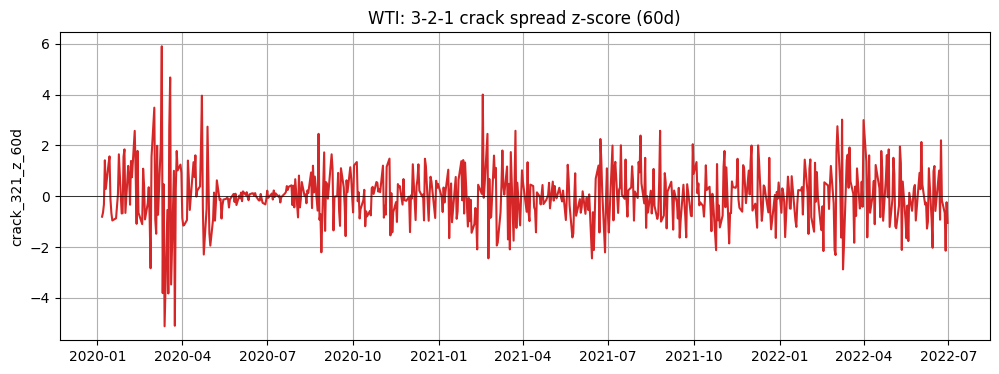

In [64]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(wti.index, wti['crack_321_z_60d'], color='tab:red', label='crack 60d z')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel('crack_321_z_60d')
ax1.set_title('WTI: 3-2-1 crack spread z-score (60d)')
ax1.grid(True)
plt.show()

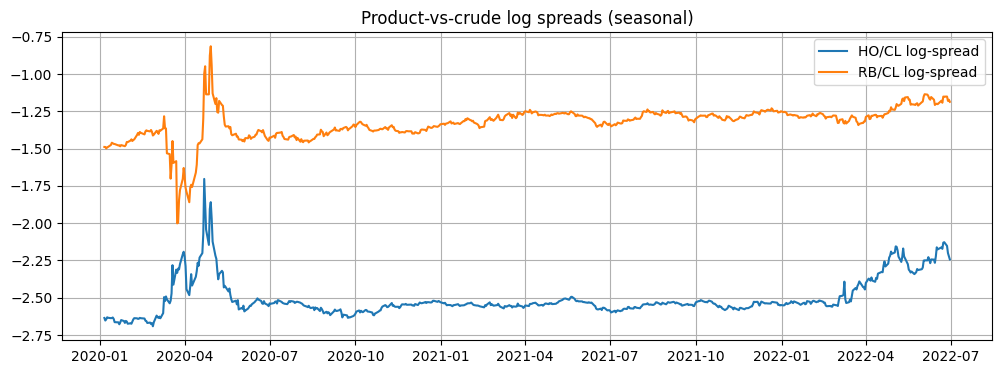

In [65]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wti.index, wti['ho_cl_spread'], label='HO/CL log-spread')
ax.plot(wti.index, wti['rb_cl_spread'], label='RB/CL log-spread')
ax.set_title('Product-vs-crude log spreads (seasonal)')
ax.legend()
ax.grid(True)
plt.show()

### 4.1 OVX Implied-Volatility Features

OVX is the CBOE Crude Oil Volatility Index, the implied-vol surface for USO options and the oil-market analogue of VIX. It is a forward-looking measure of expected WTI volatility, useful alongside the backward-looking `vol_20d`, `parkinson_20d`, and related features.

In this section we compute the following:
- `ovx_close` daily close
- `ovx_z` z-score on a 63-day window
- `iv_rv_ratio` implied vol (OVX) divided by realised vol (21-day annualised, in vol points)
- `ovx_slope` 5-day percentage change

**Why these features matter for meta-labelling**

The core idea is that options markets price in information that price-based features miss. When OVX is elevated, the market is paying up for crash protection, which usually means someone knows something or at least fears something. That is exactly the regime where a trend-following primary signal is most likely to get whipsawed.

`ovx_close` gives the raw implied vol level. On its own it is noisy, but it tells the meta-model whether the market is broadly calm or stressed. A bullish WTI crude oil signal fired into a 50 plus OVX reading deserves a lot more scepticism than the same signal at OVX 25.

`ovx_z` normalises that level against the past 63 days. An OVX of 35 is unremarkable in a high-vol year but extreme in a quiet one. The z-score is what tells the meta-model whether the market is unusually fearful relative to its recent baseline, which is the number that matters for confidence calibration.

`iv_rv_ratio` is the most informative of the four. When implied vol runs well above realised vol, options are expensive and the market is pricing in a jump that has not happened yet. That tends to mean either a real catalyst is coming or the market is being irrational, and either way signal quality drops. When IV is below RV, options are cheap, the market has stopped hedging, and price action tends to be cleaner and more trend-friendly. The ratio is a direct read on how much the market trusts its own price signals.

`ovx_slope` captures whether fear is building or fading. A sharply rising OVX over 5 days, even from a moderate level, often precedes the kind of volatile, choppy price action that kills quantitative signals. A falling OVX after a spike is the opposite, the market is calming down and directional signals start working again. The slope gives the meta-model a sense of direction, not just level.

In [66]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available, subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [67]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is the std of daily logret, annualise by sqrt(252) and scale by 100 for vol points.
    rv_pts = wti['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    wti = wti.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(wti[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     1.326382   0.015561
2022-06-27  46.990002 -0.974712     1.260500  -0.044724
2022-06-28  46.590000 -1.102164     1.301477   0.000644
2022-06-29  48.570000 -0.590286     1.334055  -0.008573
2022-06-30  48.900002 -0.479887     1.324194   0.006587


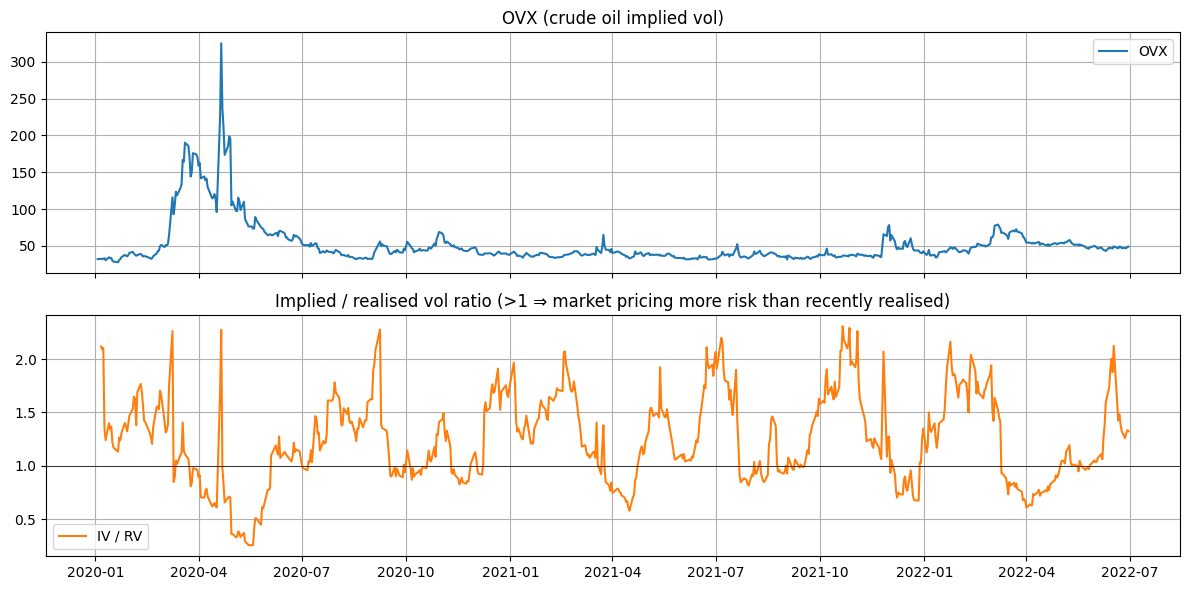

In [68]:
if 'ovx_close' in wti.columns and wti['ovx_close'].notna().any():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(wti.index, wti['ovx_close'], label='OVX')
    axes[0].set_title('OVX (crude oil implied vol)')
    axes[0].grid(True); axes[0].legend()
    axes[1].plot(wti.index, wti['iv_rv_ratio'], label='IV / RV', color='tab:orange')
    axes[1].axhline(1.0, color='k', lw=0.5)
    axes[1].set_title('Implied / realised vol ratio (>1 ⇒ market pricing more risk than recently realised)')
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.show()

## 5. Tier 3: Latent Features

These are the latent regime features learned in notebook 1. They infer the hidden state the market is in rather than just describing what prices did.

**GMM**: a 3-component Gaussian mixture on `[vol_20d, vol_of_vol_20d, parkinson_20d]`, refit walk-forward every 63 trading days with a 504-day warmup. The components are re-sorted by mean vol after every refit, so `gmm_resp_low_vol` always means low vol regardless of how a refit shuffles the labels.

**HMM**: a 2-state Gaussian HMM (calm and turbulent) on `[logret_1d, vol_20d]`, trained walk-forward on the same schedule. We use filtering, not smoothing, so `hmm_filt_*` at time `t` only depends on data up to `t`. Calling `predict_proba` on a fitted HMM runs forward-backward and uses future data inside the training window, and we deliberately do not do that. `hmm_next_turbulent` is a one-step-ahead forecast, `hmm_regime_age` is the number of days since the regime last switched, and `hmm_basket_turbulent_energy` runs the same logic across the whole energy complex.

**K-means**: K=3 on the cross-section `[ret_5d, vol_20d, volume_z_20d]` of the energy complex per day. `kmeans_cluster_size` is the fraction of instruments sharing the same cluster, so a value near 1.0 means the whole complex is co-moving while a value near 0.25 means the instruments are behaving independently.


In [69]:
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
wti[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,0.870280,0.129720,3.112956e-08,0.0,0.988803,0.011197,0.016944,10.0,0.999979,1.0,0.50
2022-06-27,0.916164,0.083836,2.135512e-08,0.0,0.977986,0.022014,0.027400,11.0,0.999921,1.0,0.50
2022-06-28,0.892143,0.107857,2.409733e-08,0.0,0.991399,0.008601,0.014436,12.0,0.999909,2.0,0.25
2022-06-29,0.933922,0.066078,1.459071e-08,0.0,0.992305,0.007695,0.013560,13.0,0.999930,2.0,0.25
2022-06-30,0.965050,0.034950,7.594412e-09,0.0,0.992119,0.007881,0.013739,14.0,0.999981,2.0,0.25


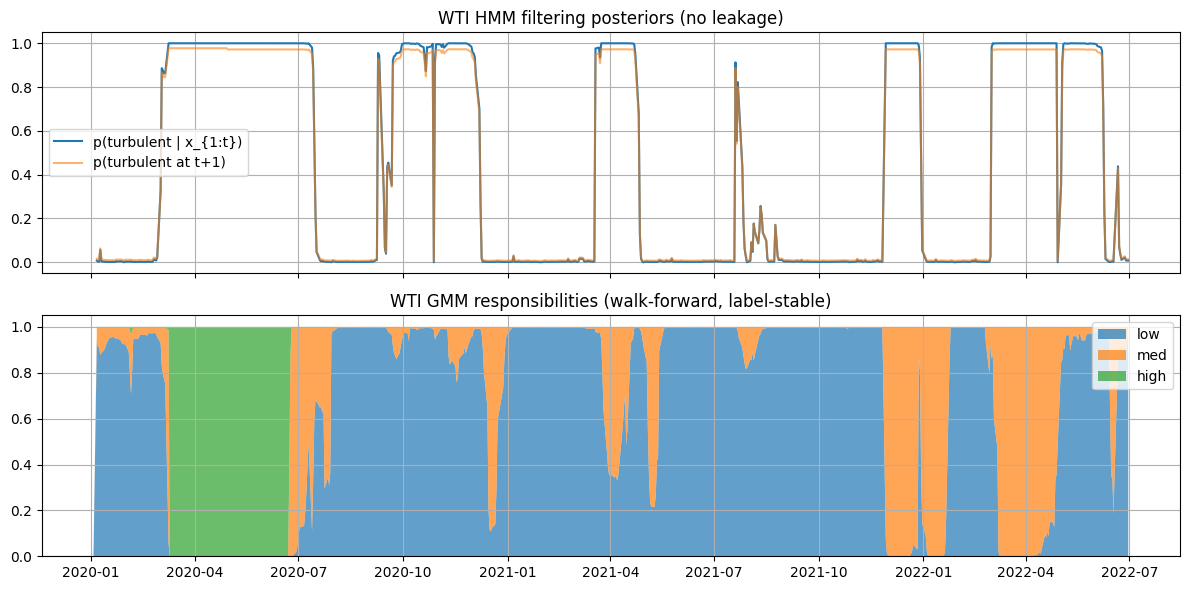

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(wti.index, wti['hmm_filt_turbulent'], label='p(turbulent | x_{1:t})')
axes[0].plot(wti.index, wti['hmm_next_turbulent'], label='p(turbulent at t+1)', alpha=0.6)
axes[0].set_title('WTI HMM filtering posteriors (no leakage)')
axes[0].legend(); axes[0].grid(True)

axes[1].stackplot(wti.index,
                  wti['gmm_resp_low_vol'].fillna(0),
                  wti['gmm_resp_med_vol'].fillna(0),
                  wti['gmm_resp_high_vol'].fillna(0),
                  labels=['low', 'med', 'high'], alpha=0.7)
axes[1].set_title('WTI GMM responsibilities (walk-forward, label-stable)')
axes[1].legend(loc='upper right'); axes[1].grid(True)
plt.tight_layout()
plt.show()

## 6. Tier 4: Primary Signal Features

Tier 4 describes the primary signal itself, including its direction, its recent lags, and how long it has been firing the same way. The meta-model needs to know what the primary strategy is doing before it can judge whether to back it.

In [71]:
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak'
]
wti[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,
2020-01-13,0.0,0.0,0.0,3.0
2020-01-14,0.0,0.0,0.0,4.0
2020-01-15,0.0,0.0,-1.0,5.0
2020-01-16,0.0,0.0,0.0,6.0
2020-01-17,0.0,0.0,0.0,7.0
2020-01-21,0.0,0.0,0.0,8.0
2020-01-22,-1.0,0.0,0.0,10.0
2020-01-23,-1.0,0.0,0.0,11.0
2020-01-24,-1.0,-1.0,0.0,12.0


## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps, standardise the features, reduce them with PCA, add the forward-only HMM regime probabilities, and split the data into a training and a test period at the signal start date. The scaling, PCA, HMM-on-PCs, and triple-barrier steps are unchanged in spirit from the simpler version, and the differences are a much bigger input (the full candidate set of roughly 70 features rather than a handful), walk-forward refits of PCA for stability across regimes, and the use of forward-only `hmm_filt_*` columns to avoid lookahead bias.

**Why this pipeline is set up this way**

**Scaling before PCA** is non-negotiable when features have different units. OVX lives around 30 to 60, the energy spreads are in price units, and the GMM responsibilities are probabilities between 0 and 1. Without StandardScaler, PCA would just find directions that explain variance in whichever feature happens to have the largest numeric range, whereas after scaling every feature gets an equal shot at influencing the principal components.

**PCA** is doing more than compression. Many of the features are correlated by construction, `ovx_z` and `ovx_close` move together, `hmm_filt_turbulent` and `gmm_resp_high_vol` are both vol-regime signals, and the spread legs overlap. Feeding correlated features straight into a downstream model inflates their effective weight and destabilises the estimates, so PCA rotates the feature space into orthogonal directions ordered by variance explained, giving the HMM and the meta-model a cleaner, lower-dimensional representation with no redundancy baked in.

**Walk-forward PCA refits** matter because the covariance structure of energy markets shifts over time. The first principal component in a calm period is not the same linear combination of features as the first PC in a stress period. A static PCA fit on the full history lets future covariance structure influence how past data is projected, which is a form of lookahead bias, so refitting on an expanding window means each day's PC scores come from a rotation that only saw data available at that point in time.

**Filtering over smoothing** is the most important constraint in the whole pipeline. The forward-backward algorithm that standard HMM implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward algorithm only means `hmm_filt_turbulent` at time `t` is a genuine real-time estimate, exactly what the model would have produced live.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [ ]:
SIGNAL_START = '2021-08-16'

# Pick the feature set you want to feed the downstream HMM.
# Start with the base and energy domain set, .

downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in wti.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

X = wti[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape)

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (406, 23) test: (221, 23)


### 7.1 PCA

We standardise the features and keep enough principal components to explain 95% of the variance. This strips out the heavy correlation between the energy features and leaves the downstream model with a compact, orthogonal representation.

In [73]:
scaler = StandardScaler()
X_train_wti = scaler.fit_transform(X_train)
X_test_wti  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_wti)
X_test_pca  = pca.transform(X_test_wti)

pc_cols = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index, columns=pc_cols)
test_pca_df  = pd.DataFrame(X_test_pca,  index=X_test.index,  columns=pc_cols)

var = pd.DataFrame({
    'PC': pc_cols,
    'ratio': pca.explained_variance_ratio_,
    'cumulative': np.cumsum(pca.explained_variance_ratio_),
})
print('PCs kept:', pca.n_components_)

PCs kept: 12


### 7.2 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [74]:
# Using a BIC Sweep for the most optimal number of clusters but it is capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

K=2: BIC=13,307.1
K=3: BIC=12,436.3
K=4: BIC=11,903.8
K=5: BIC=11,320.4
Chosen K = 5


In [75]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,
2020-01-06,-2.685906,-1.029742,-1.680819,0.522324,0.765249,-1.717964,0.690284,-1.059663,0.121317,-0.960173,-0.136132,0.110326,5.940635e-311,1.042351e-305,1.000000,0.000000e+00,8.836106e-306
2020-01-07,-2.681184,-1.041591,-1.644139,0.720325,0.400488,-1.726381,0.525804,-0.991758,0.072387,-0.792083,-0.316538,0.296120,5.094332e-131,9.945767e-08,1.000000,0.000000e+00,4.061978e-306
2020-01-08,-2.318463,-1.345284,-1.575692,0.703877,0.042190,-1.634083,0.267872,-0.880096,0.106521,-0.745335,-0.151166,0.350233,1.340165e-19,3.399085e-07,1.000000,0.000000e+00,1.912392e-15
2020-01-09,-0.611290,-2.063628,-0.799983,0.183901,-1.601282,-0.581288,-0.137468,-0.595774,-0.212678,0.501153,0.544633,0.282824,1.816332e-15,8.701922e-01,0.129808,6.661412e-24,4.597202e-12
2020-01-10,-0.836539,-1.535757,-1.084846,-0.451958,-0.597111,-0.050197,-0.817995,-0.608658,-0.558747,0.442555,0.873229,0.343199,1.318028e-10,9.997817e-01,0.000218,1.839383e-24,3.120949e-08


## 8. Triple-Barrier Meta-Labels

We label each primary signal with the triple-barrier method. A trade counts as a win if the profit-taking barrier is reached before the stop-loss or the time limit. These labels become the target the meta-model learns to predict for WTI crude oil.

**Why these barrier choices make sense for WTI crude oil:**

**Volatility scaling with EWM span 20:** The daily vol estimate uses a 20-day exponentially weighted standard deviation of log returns, and the exponential weighting is deliberate. The WTI crude oil market is event-driven. An OPEC announcement, a surprise EIA inventory print, or a Middle East escalation can double realised vol overnight. A simple rolling standard deviation treats every observation equally, so a spike three weeks ago carries the same weight as yesterday, whereas the EWM decays older observations so the vol estimate at trade entry reflects the current regime rather than a stale average. The 20-day span sits at roughly one trading month, long enough to avoid noise from a single session but short enough to adapt within a few weeks when the regime genuinely shifts.

**Symmetric barriers at pt_sl = [1.5, 1.5]:** The symmetry is intentional, it means the label is not pre-tilted toward wins or losses by construction. If the profit-take were wider than the stop-loss, the win rate would be inflated and the meta-label distribution would be harder to interpret. The 1.5 multiplier reflects WTI crude oil's return distribution, which has fat tails and persistent ranges. A multiplier of 1.0 would set barriers just one standard deviation from entry, which gets hit constantly by noise rather than genuine directional moves, while a multiplier of 2.0 or higher would push too many trades to the time barrier and degrade label quality.

**Maximum hold of 20 days:** Twenty trading days is one calendar month, which is the right horizon for a trend-following signal on an energy instrument. Signals based on regime state, energy spreads, and trend-scanning t-statistics pick up moves that play out over days to weeks, not hours, so a 5-day hold is too short for them to resolve. A 60-day hold would introduce roll risk and force the model to hold through multiple EIA reports, OPEC meetings, and seasonal transitions, all of which can reverse the original signal rationale. The EIA weekly petroleum status report lands every Wednesday, so 20 trading days covers roughly four report cycles. A signal that has not resolved after four of those cycles has probably lost its original context. A shorter hold would also push more labels to the time barrier, producing ambiguous outcomes for trades that were neither right nor wrong, so 20 days gives a reasonable fraction of clean barrier touches, which is what a well-calibrated meta-label dataset needs.

In [76]:
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        idx = close.index.searchsorted(t0)
        t1 = close.index[min(idx + max_hold, len(close.index) - 1)]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
wti_close = (
    ohlcv[ohlcv['instrument'] == 'cl1s']
    .set_index('date')['close']
    .sort_index()
)

wti_signals = wti['primary_signal'].dropna()
wti_labels = triple_barrier_meta_labels(wti_close, wti_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(wti_labels), 'win rate:', wti_labels['meta_label'].mean().round(3))
wti_labels.head()

labels: 421 win rate: 0.644


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-01-07,2020-01-08,0.013163,-1.0,pt,1
2020-01-22,2020-01-24,0.016285,-1.0,pt,1
2020-01-23,2020-01-24,0.016217,-1.0,pt,1
2020-01-24,2020-01-30,0.016500,-1.0,pt,1
2020-01-27,2020-01-31,0.016082,-1.0,pt,1


In [77]:
# Align X with the labels, same pattern as the other notebooks
y_train = wti_labels.loc[wti_labels.index <  SIGNAL_START, 'meta_label']
y_test  = wti_labels.loc[wti_labels.index >= SIGNAL_START, 'meta_label']

X_train_wti = train_pca_df.reindex(y_train.index).dropna()
X_test_wti  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_wti.index]
y_test  = y_test.loc[X_test_wti.index]

print(X_train_wti.shape, y_train.shape)
print(X_test_wti.shape,  y_test.shape)

(259, 17) (259,)
(162, 17) (162,)


## 9. Models

In this section we build the meta-models with logistic regression, random forest, XGBoost, and three neural networks. We compare them with walk-forward cross-validation, which respects the time order of the data and scores each candidate by AUC across the expanding folds, then retrain the best of each on the full training set and evaluate once on the held-out test set.

In [78]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


### 9.1 Logistic Regression

A linear baseline. With only a few hundred labelled training observations, regularisation is the parameter that matters most, so the grid sweeps the inverse regularisation strength `C` across both L2 and L1 penalties and adds balanced class weights for the imbalanced meta-label distribution. L2 keeps every coefficient small, while L1 can zero out the low-variance PCs that survived the 95% variance threshold, which on a small sample often generalises better because it commits to fewer signals rather than spreading weight across all of them. We avoid effectively unregularised settings, since on this sample size they overfit the CV folds and any win is likely an artefact of a favourable split.

In [79]:
# Logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_wti, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
 1.00      l1         None  0.597857 0.145985
 0.10      l1         None  0.576725 0.122027
 1.00      l2         None  0.524070 0.171871
 1.00      l2     balanced  0.521485 0.170566
10.00      l2         None  0.518271 0.203213
 0.10      l2         None  0.507696 0.137366
 0.10      l2     balanced  0.500728 0.131690
 0.01      l2         None  0.450466 0.082427


### 9.2 Random Forest

A bagged tree model that captures non-linear interactions between the regime features and signal quality. On a few hundred observations the leaf size is the primary regularisation lever, since a leaf of only a handful of samples lets the tree learn splits tied to specific dates rather than anything that looks like a regime. The grid therefore tunes the tree depth, the minimum samples per leaf, the number of features considered at each split, and the class weighting, keeping the depth shallow enough to avoid spurious interactions while still allowing the few splits it takes to express a condition like a bullish signal in a high-OVX, turbulent regime.

In [ ]:
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.

rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 1, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          200          5                 5  0.538241 0.156774
          200          5                10  0.520721 0.121409
          200          8                10  0.520276 0.121244
          200          5                10  0.513437 0.135651
          200          1                20  0.506976 0.087570
          100          8                 5  0.499061 0.134885
          100          5                 5  0.494793 0.131162
          100          3                 5  0.494418 0.133497


### 9.3 XGBoost

A gradient-boosted tree model. We tune the learning rate, the depth, the subsample and column-sample fractions, and we use `scale_pos_weight` to handle the class imbalance. The most important regularisation lever on a small dataset is `min_child_weight`, the minimum sum of instance weights required in a leaf, which is XGBoost's equivalent of a minimum leaf size. At its default of 1 a leaf can represent a single observation, which on a few hundred samples is memorisation rather than learning, so we keep the trees shallow and the leaves well populated so that each split is supported by enough data to generalise across different market conditions.

In [81]:
# XGBoost parameter grid, we try several settings and keep the best
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 0.68  (n_neg=105, n_pos=154)
 n_estimators  learning_rate  max_depth  subsample  scale_pos_weight  mean_auc  std_auc
          100           0.05          3        0.8          1.000000  0.570984 0.210941
          100           0.10          5        0.7          1.000000  0.568897 0.173848
          100           0.05          5        0.8          1.000000  0.564748 0.214711
          200           0.05          5        0.8          1.000000  0.560914 0.190428
          200           0.05          3        0.8          1.000000  0.559591 0.193621
          200           0.05          3        0.8          0.681818  0.559046 0.196800
          200           0.05          5        0.8          0.681818  0.558401 0.198979
          100           0.10          3        0.8          1.000000  0.524363 0.193732


### 9.4 Retrain Best Models and Evaluate on Test

We refit the best logistic regression, random forest, and XGBoost on the full training set and score them once on the held-out test set. The ROC curve shows how well the strongest model separates winning from losing trades, and the AUC summarises that separation in a single number.

In [82]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_wti, y_train)
    proba = model.predict_proba(X_test_wti)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.6942
RF  test AUC: 0.6777
XGB  test AUC: 0.6198


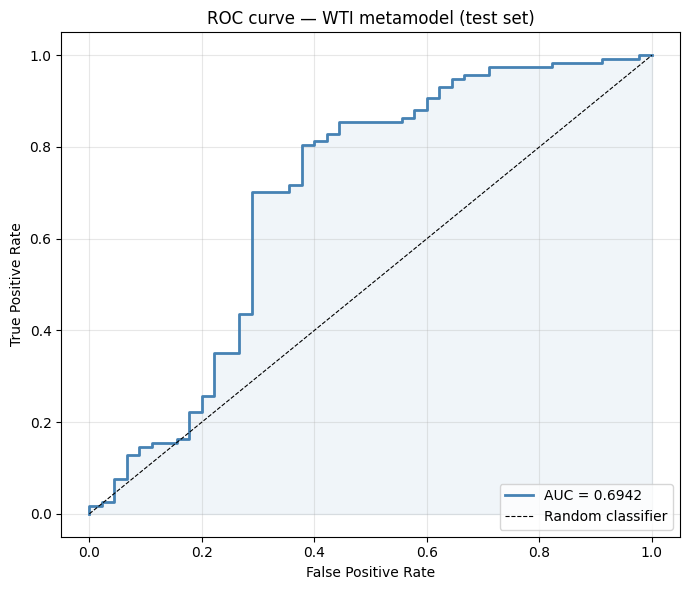

Test AUC: 0.6942


In [83]:

best_model = best_lr  # swap to best_lr or best_rf if needed

proba = best_model.predict_proba(X_test_wti)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve, WTI crude oil meta-model (test set)')

ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Test AUC: {auc:.4f}')

### 9.5 Neural Network Setup

The neural networks need their own feature scaling and their own walk-forward cross-validation helper, which trains a freshly compiled Keras model on each fold and scores it by AUC. Building this once keeps the three network sections below consistent with the walk-forward discipline used for the classical models.

In [84]:
scaler_nn = StandardScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_wti.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_wti.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=17, pos_weight=0.68


In [85]:
# Neural network models

# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [86]:
# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

### 9.6 MLP

A feedforward network with two hidden layers, batch normalisation, dropout, and a sigmoid output. The tunable parameters are the layer width, the dropout rate, and the learning rate. With only a few hundred training samples, dropout is the primary regularisation lever, so wider networks are paired with more aggressive dropout to stay generalised. We keep the depth fixed at two layers, since more depth needs more data to train reliably and would add noise to the search rather than useful signal.

In [87]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.6662 std=0.1303
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5775 std=0.2030
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.6608 std=0.1274
hidden=128 dropout=0.3 lr=0.001  mean_auc=0.7508 std=0.1111
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.4971 std=0.2167
hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.5750 std=0.1543

Best MLP: {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.001}


### 9.7 Variable Selection Network (VSN)

The VSN learns a softmax weight over the input features at each forward pass, so unlike the MLP, which treats every PC equally, it can suppress features that are not useful in the current regime and up-weight the ones that are. That dynamic selection is genuinely useful for WTI crude oil meta-labelling, where feature relevance shifts across seasons and macro regimes, and the learned weights are interpretable as a bonus. The extra attention layer adds capacity, which makes overfitting more likely on a small sample, so the dropout floor is raised relative to the MLP and the wider configurations use a slower learning rate to give the attention weights time to settle rather than collapsing to uniform values early in training.

In [88]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have ~70 features
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.4930 std=0.1803
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.6508 std=0.1572
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.6627 std=0.1481
hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.7159 std=0.1673
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5640 std=0.1562

Best VSN: {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.0005}


### 9.8 LSTM

The LSTM looks at a sequence of the last few days before each trade entry, so it can pick up the temporal pattern leading into the trade rather than a single snapshot. The main tension is between the sequence length, where a longer window gives more context but leaves fewer usable training sequences, and the model capacity, where deeper recurrence risks overfitting. We tune the sequence length, the hidden size, the number of layers, and the dropout, keeping short windows shallow since one or two layers are enough for the temporal dependencies in a short window, and we treat the longest lookback with caution because a high sequence-to-sample ratio is hard to generalise from on a few hundred observations.

In [89]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_wti.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_wti, X_test_wti]).values),
    index=pd.concat([X_train_wti, X_test_wti]).index,
    columns=X_train_wti.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 5e-4},
    {'seq_len': 60, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.5502 std=0.2206
seq=10 hidden=64 layers=2  mean_auc=0.6991 std=0.1096
seq=20 hidden=32 layers=1  mean_auc=0.7059 std=0.0375
seq=20 hidden=64 layers=2  mean_auc=0.7606 std=0.1730
seq=20 hidden=64 layers=2  mean_auc=0.7174 std=0.1578
seq=60 hidden=64 layers=2  mean_auc=0.5942 std=0.2788

Best LSTM: {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}


### 9.9 Final Neural Network Results

We refit each network on the full training set with its best hyperparameters and record its test AUC alongside the classical models, so all six models are compared on the same held-out period.

In [90]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.4653
VSN  test AUC: 0.5178
LSTM test AUC: 0.3020


## 10. Evaluation

Finally we collect the predicted probabilities from every model and sweep the decision threshold from low to high. The precision, recall, and F1 curves show the trade-off as we make the meta-model more or less selective, a higher threshold takes fewer trades but demands more confidence in each while a lower threshold takes more. Reading the curves together is what tells us where the meta-model adds the most value on top of the primary signal.

In [91]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_wti)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_wti)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_wti)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [92]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades), # Total number of trades due to labeling
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4), # The amount of trades taken
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        68       42.0     0.8088  0.4701 0.5946 0.6942
      0.35        55       34.0     0.7818  0.3675 0.5000 0.6942
      0.40        45       27.8     0.7778  0.2991 0.4321 0.6942
      0.45        34       21.0     0.7647  0.2222 0.3444 0.6942
      0.50        28       17.3     0.7143  0.1709 0.2759 0.6942
      0.55        20       12.3     0.8000  0.1368 0.2336 0.6942
      0.60        16        9.9     0.8125  0.1111 0.1955 0.6942
      0.65        15        9.3     0.8000  0.1026 0.1818 0.6942
      0.70        13        8.0     0.7692  0.0855 0.1538 0.6942
      0.75        12        7.4     0.7500  0.0769 0.1395 0.6942
      0.80        11        6.8     0.8182  0.0769 0.1406 0.6942

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       158       97.5     0.7405  1.0000 0.8509 0.6777
      0.35       153       94.4     0.7647  1.0000 0.8

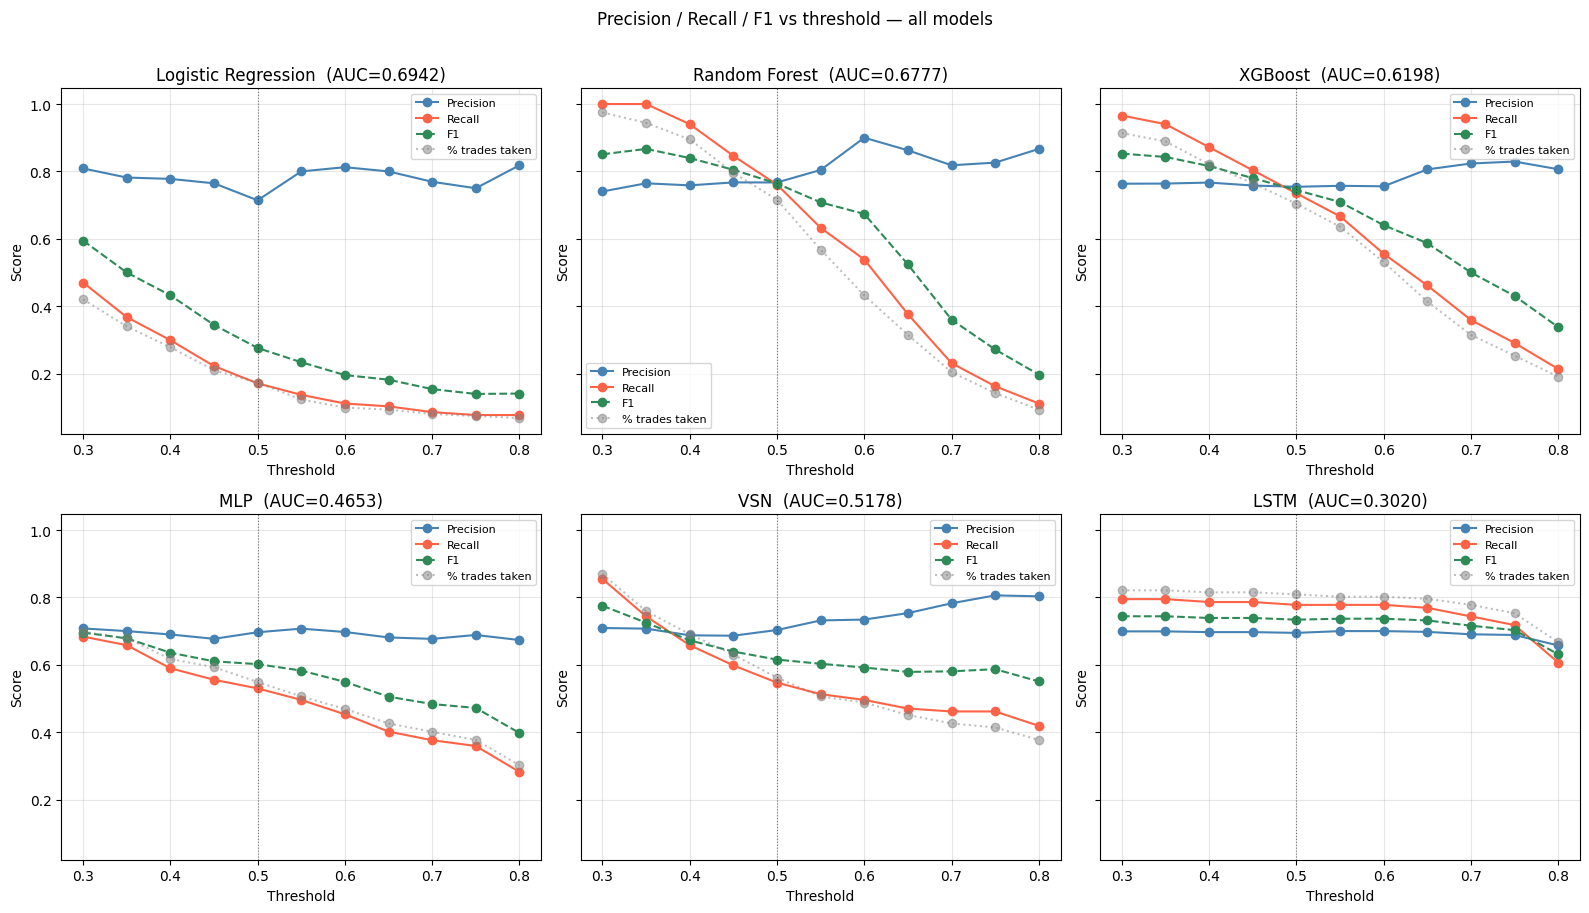

In [93]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold, all models', y=1.01)
plt.tight_layout()
plt.show()